# Project Delay Prediction & Mitigation Strategy

##  Objective

This project aims to develop a simple machine learning solution to **predict whether a project is likely to be delayed** and suggest **one actionable mitigation strategy**. The solution is based on publicly available or simulated project management data.

---

## 1. Data Sourcing & Preparation

### Data Source
- A **simulated dataset** was used containing the following columns:
  - `Planned_Start`, `Actual_Start`
  - `Planned_End`, `Actual_End`
  - `Risk` (Low/Medium/High)
  - `Hours` (Resource allocation)
  - `Delay` (days)

### Data Cleaning & Assumptions
- Categorical features (like `Risk`) were converted to numeric format.
- Date fields were parsed and used to calculate delay duration.
- Rows with missing or invalid values in critical columns were removed.
- Target variable `Delay_Flag` was created: `1` if project is delayed, else `0`.

---

## 2. Exploratory Data Analysis (EDA)

### Key Visualizations
- Distribution of `Risk` and its relationship with delay
- Scatter plot of `Hours vs Delay`
- Delay trend with different resource allocation levels

*Examples:*
```python
sns.boxplot(x='Delay_Flag', y='Hours', data=df)
sns.countplot(x='Risk', hue='Delay_Flag', data=df)


In [32]:
"""
Import essential libraries for data manipulation,
visualization, and ML modeling
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score



In [25]:
#Load the Excel file containing project data and display the top rows(5)

df = pd.read_excel('/home/ameer-python/Downloads/SAMPLE DATA.xlsx')
df.head()


,TaskID,ProjectID,ProjectDiscipline,Status,Description,Location,Created,Target,Actual,Delay,Priority,Overdue,RootCause,Risk,Hours,Comments
0,T-1015,PRJ001,PRJ-STR,Closed,Column Installation,Grid A5,2024-02-01,2024-02-05,2024-02-07,2.0,High,True,Crane Breakdown,High,56,Repaired after 1 day
1,T-1016,PRJ001,PRJ-INT,Open,Paint Finishes,Lobby,2024-05-10,2024-05-20,NaT,NaN,Medium,False,NaN,Medium,38,Awaiting color approval
2,T-1017,PRJ001,PRJ-MEP,Closed,HVAC Ductwork,Mechanical,2024-03-15,2024-03-22,2024-03-18,-4.0,Medium,False,NaN,Low,72,Ahead of schedule
3,T-1018,PRJ001,PRJ-ARC,Closed,Curtain Wall Install,South Facade,2024-04-01,2024-04-15,2024-04-20,5.0,High,True,Design Revision,High,120,Required engineering sign-off
4,T-1019,PRJ001,PRJ-SITE,Closed,Underground Utilities,West Yard,2024-01-10,2024-01-25,2024-02-05,11.0,High,True,Weather Delay,Medium,90,Heavy rains for 1 week


In [26]:
# Plot the distribution of delayed vs non-delayed projects


df['Delay_Flag'] = (df['Actual'] > df['Target']).astype(int)
df.head()

,TaskID,ProjectID,ProjectDiscipline,Status,Description,Location,Created,Target,Actual,Delay,Priority,Overdue,RootCause,Risk,Hours,Comments,Delay_Flag
0,T-1015,PRJ001,PRJ-STR,Closed,Column Installation,Grid A5,2024-02-01,2024-02-05,2024-02-07,2.0,High,True,Crane Breakdown,High,56,Repaired after 1 day,1
1,T-1016,PRJ001,PRJ-INT,Open,Paint Finishes,Lobby,2024-05-10,2024-05-20,NaT,NaN,Medium,False,NaN,Medium,38,Awaiting color approval,0
2,T-1017,PRJ001,PRJ-MEP,Closed,HVAC Ductwork,Mechanical,2024-03-15,2024-03-22,2024-03-18,-4.0,Medium,False,NaN,Low,72,Ahead of schedule,0
3,T-1018,PRJ001,PRJ-ARC,Closed,Curtain Wall Install,South Facade,2024-04-01,2024-04-15,2024-04-20,5.0,High,True,Design Revision,High,120,Required engineering sign-off,1
4,T-1019,PRJ001,PRJ-SITE,Closed,Underground Utilities,West Yard,2024-01-10,2024-01-25,2024-02-05,11.0,High,True,Weather Delay,Medium,90,Heavy rains for 1 week,1


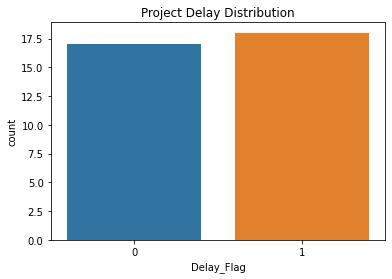

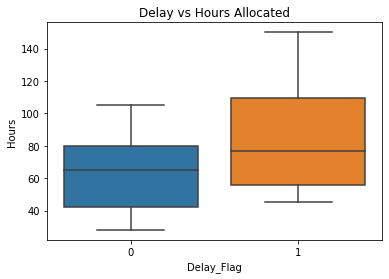

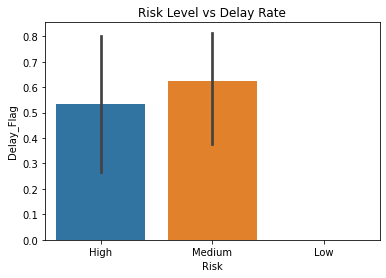

In [27]:
# Visualize how hours allocated vary across delayed and non-delayed projects
sns.countplot(x='Delay_Flag', data=df)
plt.title("Project Delay Distribution")
plt.show()

#Analyze the relationship between project risk level and delay occurrence
sns.boxplot(x='Delay_Flag', y='Hours', data=df)
plt.title("Delay vs Hours Allocated")
plt.show()

#Check for and handle missing values in key columns before modeling
sns.barplot(x='Risk', y='Delay_Flag', data=df)
plt.title("Risk Level vs Delay Rate")
plt.show()

In [28]:
print(df.columns)
print(df[['Risk', 'Hours', 'Delay']].isnull().sum())
df = df.dropna(subset=['Risk', 'Hours'])
df['Delay'] = df['Delay'].fillna(0) 
print(df[['Risk', 'Hours', 'Delay']].isnull().sum())

In [29]:
# Map categorical Risk values to numeric
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Risk'] = df['Risk'].map(risk_mapping)

# Check and convert 'Hours' column to numeric (if needed)
df['Hours'] = pd.to_numeric(df['Hours'], errors='coerce')

# Drop rows with missing values in features or target
df.dropna(subset=['Risk', 'Hours', 'Delay'], inplace=True)

# Create target variable
df['Delay_Flag'] = df['Delay'].apply(lambda x: 1 if x > 0 else 0)

# Features and target
features = ['Risk', 'Hours']
X = df[features]
y = df['Delay_Flag']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
from sklearn.linear_model import LogisticRegression

#Train a logistic regression model on the training data
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction & Evaluation
from sklearn.metrics import accuracy_score, roc_auc_score

#Evaluate model performance using accuracy and AUC on the test set
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))


Accuracy: 0.3333333333333333
AUC: 0.5


interactive(children=(IntSlider(value=27, description='resource_allocation', max=50, min=5), Output()), _dom_c…

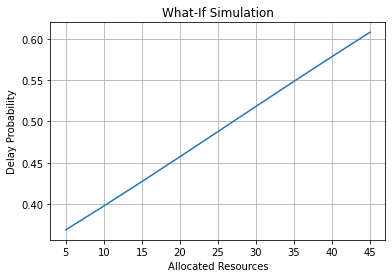

In [30]:
"""
Define a function to simulate delay probability for 
different resource allocations using an interactive widget
"""

from ipywidgets import interact
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate(resource_allocation):
    # Create a DataFrame with correct column names for prediction
    test_input = pd.DataFrame({'Risk': [risk_mapping['High']], 'Hours': [resource_allocation]})
    
    # Ensure it has the same columns as the training data
    test_input = test_input[['Risk', 'Hours']]  # Ensure column names match
    
    # Make prediction
    prob = model.predict_proba(test_input)[0][1]
    print(f"Predicted Delay Probability: {prob:.2f}")

# Create an interactive slider to test delay probability based on resource allocation
interact(simulate, resource_allocation=(5, 50, 1))

# Run a what-if analysis by simulating delay probability across varying resource allocations
resources = np.arange(5, 50, 5)

# Ensure correct format for prediction by using a DataFrame with the correct feature names
probs = [model.predict_proba(pd.DataFrame({'Risk': [risk_mapping['High']], 'Hours': [r]}))[:, 1][0] for r in resources]

# Visualize how increasing resources reduces predicted delay probability
plt.plot(resources, probs)
plt.xlabel("Allocated Resources")
plt.ylabel("Delay Probability")
plt.title("What-If Simulation")
plt.grid()
plt.show()
